In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('E:/CIENCIA DE DATOS E IA/2-SEGUNDO AÑO\SEGUNDO CUATRIMESTRE/2- LABORATORIO DE MINERIA Y DATOS/Proyecto_AndesLink/data/churn_sintetico.csv')
print(df.head())

   tenure_months  monthly_charge  total_charges  support_tickets  \
0              7           58.23         326.50                2   
1             56           56.75        3154.21                0   
2             48           78.84        3864.31                3   
3             32           79.74        2511.40                0   
4             32           55.37        1735.51                3   

   late_payments  avg_monthly_usage_gb contract_type payment_method  \
0              1                 81.83       mensual  transferencia   
1              2                 96.52         anual         debito   
2              2                 93.60       bianual       efectivo   
3              0                 28.95       bianual         debito   
4              0                126.90         anual       efectivo   

  internet_service  has_streaming  has_security_pack  num_products  region  \
0            cable              0                  1             3  centro   
1       

In [4]:
df.shape 

(5000, 16)

In [5]:
df.isnull().sum()

tenure_months           0
monthly_charge          0
total_charges           0
support_tickets         0
late_payments           0
avg_monthly_usage_gb    0
contract_type           0
payment_method          0
internet_service        0
has_streaming           0
has_security_pack       0
num_products            0
region                  0
customer_age            0
is_promo                0
churn                   0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
edad_maxima = df['customer_age'].max()
edad_minima = df['customer_age'].min()
print(f"La edad máxima de los clientes es: {edad_maxima}")
print(f"La edad máxima de los clientes es: {edad_minima}")

La edad máxima de los clientes es: 78
La edad máxima de los clientes es: 18


In [8]:
print (f"Cantidad de Clientes según el Tipo de Servicio")
servicios_top = df['internet_service'].value_counts()
print(servicios_top)

Cantidad de Clientes según el Tipo de Servicio
internet_service
fibra      2240
cable      1423
movil      1000
ninguno     337
Name: count, dtype: int64


In [9]:
Abandono_de_servicios = df['churn'].value_counts()
print (f"Cantidad Total de Clientes que Abandonaron (1)")
print(Abandono_de_servicios)

Cantidad Total de Clientes que Abandonaron (1)
churn
0    3298
1    1702
Name: count, dtype: int64


In [10]:
print (f"% de Abandono según el Tipo de Servicio")
print(df.groupby('internet_service')['churn'].mean() * 100)

% de Abandono según el Tipo de Servicio
internet_service
cable      34.785664
fibra      26.830357
movil      50.900000
ninguno    28.783383
Name: churn, dtype: float64


In [11]:
print (f"% de Abandono según el Tipo de Servicio")
print(df.groupby('has_security_pack')['churn'].mean() * 100)

% de Abandono según el Tipo de Servicio
has_security_pack
0    35.071708
1    33.160430
Name: churn, dtype: float64


In [12]:
print (f"% de Abandono según el Tipo de Servicio")
print(df.groupby('has_streaming')['churn'].mean() * 100)

% de Abandono según el Tipo de Servicio
has_streaming
0    34.578313
1    33.772455
Name: churn, dtype: float64


In [13]:
clientes_que_abandonan = df['churn'].value_counts()
print (f"% de Churn según el tipo de servicio")
print(df.groupby('internet_service')['churn'].mean() * 100)
print (f"Cantidad Total de Clientes que se fueron (1)")
print(clientes_que_abandonan)

% de Churn según el tipo de servicio
internet_service
cable      34.785664
fibra      26.830357
movil      50.900000
ninguno    28.783383
Name: churn, dtype: float64
Cantidad Total de Clientes que se fueron (1)
churn
0    3298
1    1702
Name: count, dtype: int64


In [14]:
# Primeras Observaciones:
# has_security Pack (35% vs 33%): La diferencia es mínima (solo 2%). Tener o no tener el paquete de seguridad no parece influir en que el cliente se quede o se vaya.
# has_reaming (34.5% vs 33.7%): Aquí la diferencia es de menos del 1%. Es prácticamente irrelevante.
# internet_service aquí tenemos el mayor porcentaje, la mitad de los que tienen este servicio se van.
# Cable: 34.7%
# Ninguno: 28.7%
# Fibra: 26.8%

C:\Users\resqu\AppData\Local\Temp\ipykernel_12056\1228897993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='viridis')


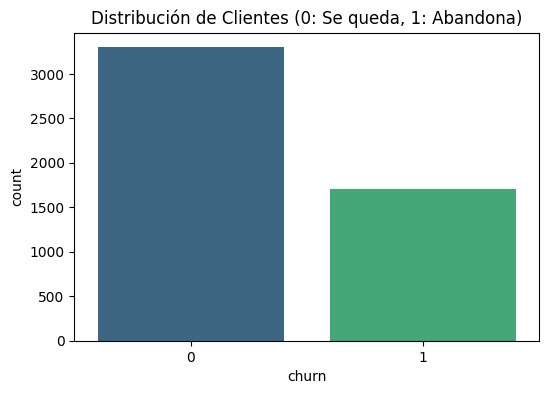

In [15]:
#1 Visualizar la distribución de Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Distribución de Clientes (0: Se queda, 1: Abandona)')
plt.show()

In [16]:
#Distribución de Clientes (Gráfico de Barras)

# La gran mayoría de los clientes se mantienen (0), pero tenemos una cantidad significativa de abandonos (1), aproximadamente 1/3 abandono.

# Interpretación: Visualmente, parece que el churn representa aproximadamente un 30-35% de la base total.

# Para entrenar un modelo de Machine Learning más adelante, este "desbalance" es importante.
# Si el grupo 1 fuera mucho más pequeño, tendrías que usar técnicas especiales (como sobremuestreo), para que el modelo aprenda bien a identificar a los que se van.

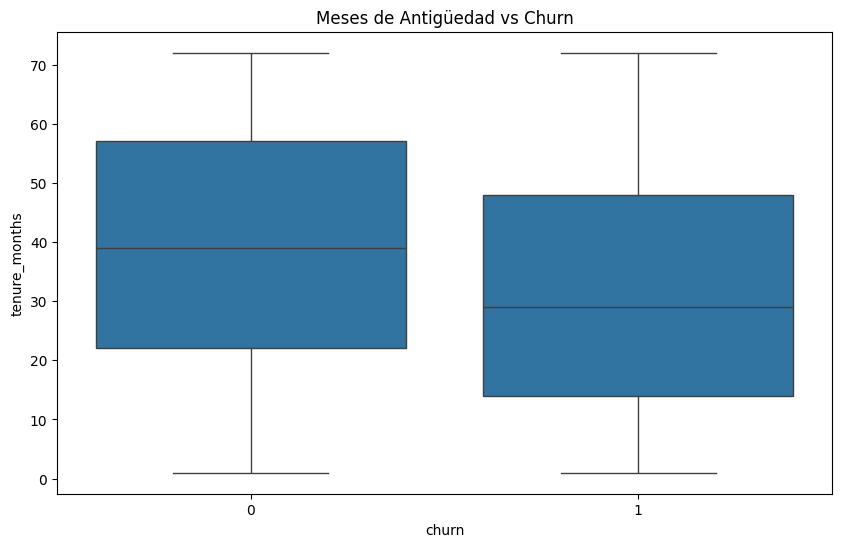

In [17]:
#2 Relación: Antigüedad vs Churn (Hipótesis: ¿los nuevos se van más?)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='churn', y='tenure_months')
plt.title('Meses de Antigüedad vs Churn')
plt.show()

In [18]:
# Meses de Antigüedad vs. Churn (Boxplot)

#Aquí comparamos la "lealtad" en tiempo. El boxplot muestra la mediana (la línea negra central) y la dispersión del 50% de los datos (la caja azul).

# Osea los clientes que se quedan (0) tienen una mediana de antigüedad notablemente más alta (cerca de los 40 meses), que los que se van (1) (cuya mediana está cerca de los 30 meses).

# La hipótesis de que "los nuevos se van más" parece ser correcta. 
# La caja del grupo 1 está más abajo en el eje Y, lo que indica que el riesgo de abandono es mayor durante los primeros dos años y medio de contrato.

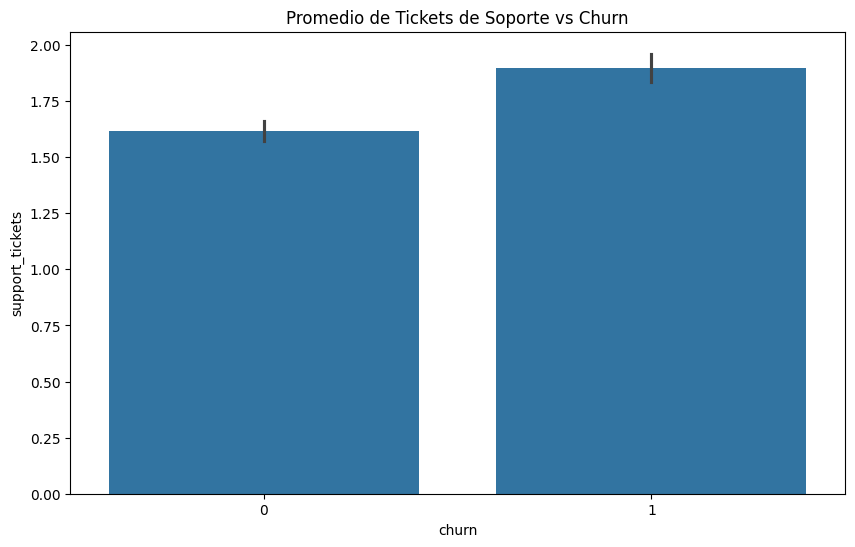

In [19]:
#3 Relación: Tickets de Soporte vs Churn
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='churn', y='support_tickets')
plt.title('Promedio de Tickets de Soporte vs Churn')
plt.show()

In [20]:
# Promedio de Tickets de Soporte vs. Churn

# Este gráfico muestra la relación entre la frustración técnica/administrativa y la salida del cliente.

# Existe una correlación clara. Los clientes que abandonan generan, en promedio, más tickets de soporte (cerca de 1.9) que los que se quedan (aprox. 1.6).

# La fricción en el servicio es un disparador del abandono.
# Las pequeñas líneas negras arriba de las barras (barras de error) son cortas,lo que significa que esta diferencia es estadísticamente significativa y no es fruto del azar.

In [21]:
# Posibles Estrategias:

# Tenemos un problema de retención concentrado en los clientes más nuevos (menos de 30 meses), y en aquellos que experimentan problemas técnicos recurrentes (reflejado en el mayor volumen de tickets). 
# Para bajar el churn, deberíamos enfocarnos en mejorar la experiencia de soporte.
# Y crear planes de fidelización para los clientes que llevan menos de dos años con nosotros. 

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Obtenemos las importancias
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False).head(10)

# 2. Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='magma')
plt.title('Top 10 Variables más influyentes en el Churn (AndesLink)')
plt.show()

NameError: name 'model' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
churn_by_service = df.groupby('internet_service')['churn'].mean() * 100
sns.barplot(x=churn_by_service.index, y=churn_by_service.values, palette='Reds_r')
plt.title('Porcentaje de Abandono por Tipo de Servicio')
plt.ylabel('% de Churn')
plt.axhline(df['churn'].mean()*100, color='black', linestyle='--', label='Promedio General')
plt.legend()
plt.show()

In [22]:
# Conectamos con DagsHub
import dagshub
dagshub.init(repo_owner='JuanManuelResquin84', repo_name='Proyecto_AndesLink', mlflow=True)

import mlflow
with mlflow.start_run():
  mlflow.log_param('parameter name', 'value')
  mlflow.log_metric('metric name', 1)

ModuleNotFoundError: No module named 'dagshub'

In [22]:
# Preparamos los datos para el entrenamiento
import pandas as pd
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#1 Preparación de Datos (Copia y Limpieza)
df_ml = df.copy()

#2 Encoding
# Usamos One-Hot Encoding para las características (X)
# Esto crea columnas de 0 y 1 para categorías como 'plan_internet' o 'genero'
X = pd.get_dummies(df_ml.drop('churn', axis=1), drop_first=True)

#2 Usamos LabelEncoder solo para la variable objetivo (y)
le = LabelEncoder()
y = le.fit_transform(df_ml['churn'])

#3 División del Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
# Entrenamiento y Tracking con MLflow
with mlflow.start_run(run_name="RandomForest_1"):
    # Configuramos el modelo
    n_est = 100
    max_d = 5
    model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Loggeamos todo a DagsHub
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.7090

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       660
           1       0.70      0.25      0.37       340

    accuracy                           0.71      1000
   macro avg       0.70      0.60      0.59      1000
weighted avg       0.71      0.71      0.66      1000

🏃 View run RandomForest_1 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/a8f6a250cf5e4998939cb4dfee6edb75
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [33]:
# Entrenamiento y Tracking con MLflow
with mlflow.start_run(run_name="RandomForest_2"):
    # Configuramos el modelo
    n_est = 60
    max_d = 5
    model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Loggeamos todo a DagsHub
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.7040

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.94      0.81       660
           1       0.68      0.25      0.36       340

    accuracy                           0.70      1000
   macro avg       0.69      0.59      0.58      1000
weighted avg       0.70      0.70      0.66      1000

🏃 View run RandomForest_2 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/081d3d47e24b474f88afe4159d07c91c
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [34]:
    # Entrenamiento y Tracking con MLflow
    with mlflow.start_run(run_name="RandomForest_3"):
        # Configuramos el modelo
        n_est = 150
        max_d = 5
        model = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
        
        # Entrenamos
        model.fit(X_train, y_train)
        
        # Predecimos y evaluamos
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        # Loggeamos todo a DagsHub
        mlflow.log_param("model_type", "RandomForest")
        mlflow.log_param("n_estimators", n_est)
        mlflow.log_param("max_depth", max_d)
        mlflow.log_param("encoding_type", "OneHot")
        mlflow.log_metric("accuracy", accuracy)
        
        print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
        print("\nReporte de Clasificación:")
        print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.7160

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.72      0.94      0.81       660
           1       0.71      0.28      0.40       340

    accuracy                           0.72      1000
   macro avg       0.71      0.61      0.61      1000
weighted avg       0.71      0.72      0.67      1000

🏃 View run RandomForest_3 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/0d8894c9c22049f2ac00d6e4e1a8fc71
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [35]:
# BALANCEO DE CLASES:ya que anteriormente el modelo trata a todos los errores por igual. 
# Agragando el parámetro class_weight='balanced' en tu RandomForest. Esto le dice al modelo que preste más atención a los clientes que abandonan.

with mlflow.start_run(run_name="RandomForest_4_Balanceado"):
    # Configuramos el modelo
    n_est = 150
    max_d = 7 
    
    # IMPORTANTE: El class_weight va dentro del constructor del modelo
    model = RandomForestClassifier(
        n_estimators=n_est, 
        max_depth=max_d, 
        class_weight='balanced', # <--- Ahora sí el modelo lo usa
        random_state=42
    )
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Loggeamos todo a DagsHub
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("class_weight", "balanced") # Agregamos esto al log para comparar
    mlflow.log_param("encoding_type", "OneHot")
    mlflow.log_metric("accuracy", accuracy)
    
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.6770

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.68      0.73       660
           1       0.52      0.68      0.59       340

    accuracy                           0.68      1000
   macro avg       0.66      0.68      0.66      1000
weighted avg       0.71      0.68      0.68      1000

🏃 View run RandomForest_4_Balanceado at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/53b76a92bf4e4fc7a9816e294c9144f8
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [36]:
with mlflow.start_run(run_name="RandomForest_5"):
    
    # Configuramos el modelo con los pesos manuales que nos dieron el "punto dulce"
    n_est = 200
    max_d = 10
    pesos = {0: 1, 1: 1.8} 
    
    model = RandomForestClassifier(
        n_estimators=n_est, 
        max_depth=max_d, 
        class_weight=pesos,
        random_state=42
    )
    
    # Entrenamos
    model.fit(X_train, y_train)
    
    # Predecimos y evaluamos
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    # --- LOGS PARA DAGSHUB (Para que aparezcan en la tabla de tu imagen) ---
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_est)
    mlflow.log_param("max_depth", max_d)
    mlflow.log_param("encoding_type", "OneHot") # Ahora sí aparecerá en la web
    mlflow.log_param("class_weight_ratio", "1:1.8")
    
    # Registramos la métrica principal
    mlflow.log_metric("accuracy", accuracy)
    
    # Mostramos resultados en consola
    print(f"Entrenamiento terminado. Accuracy: {accuracy:.4f}")
    print("\nReporte de Clasificación (Mirar el Recall de la clase 1):")
    print(classification_report(y_test, y_pred))

Entrenamiento terminado. Accuracy: 0.6960

Reporte de Clasificación (Mirar el Recall de la clase 1):
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       660
           1       0.55      0.59      0.57       340

    accuracy                           0.70      1000
   macro avg       0.66      0.67      0.67      1000
weighted avg       0.70      0.70      0.70      1000

🏃 View run RandomForest_5 at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0/runs/4cde0e130888499c9285ac498a969ec4
🧪 View experiment at: https://dagshub.com/JuanManuelResquin84/Proyecto_AndesLink.mlflow/#/experiments/0


In [ ]:
# Ahora procedo a utilizar la librería de PyCaret, buscando reducir el tiempo para el despliegue de los distintos modelos y poder elegir el más optimo. 

# Configuración del Entorno

=